In [10]:
import pandas as pd
data = pd.read_csv("WineQT.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [12]:
data = data.drop(['Id'], axis=True)

In [14]:
# Remove all duplicates except the first occurrence
data_deduplicated = data.drop_duplicates(keep='first')

# Show new shape after removing duplicates
data_deduplicated.shape


(1018, 12)

In [16]:
# Seperate the data and label
X = data.drop(['quality'], axis=True)

# Binarize the label
Y=data['quality']

In [18]:
from imblearn.over_sampling import SMOTE

os = SMOTE()
X_res, Y_res = os.fit_resample(X, Y)


In [20]:
# Splitting test-train split

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_res, Y_res, test_size = 0.2, random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler

stdscale=StandardScaler().fit(X_train)
X_train=stdscale.transform(X_train)
X_test=stdscale.transform(X_test)

In [26]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'max_features': ['sqrt', 'log2']
}

In [28]:
# Check RandomForestClassifier accuracy from random_state 1 to 5

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

best_result_summary_1_5 = None

for state in range(1, 6):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_1_5 is None or acc > best_result_summary_1_5['accuracy']:
                    best_result_summary_1_5 = result

# Final best summary from this range
best_result_summary_1_5_full = {
    'Best Parameters': {
        'random_state': best_result_summary_1_5['random_state'],
        'n_estimators': best_result_summary_1_5['n_estimators'],
        'max_depth': best_result_summary_1_5['max_depth'],
        'max_features': best_result_summary_1_5['max_features']
    },
    'Accuracy': best_result_summary_1_5['accuracy'],
    'Classification Report': best_result_summary_1_5['report']
}

best_result_summary_1_5_full


{'Best Parameters': {'random_state': 3,
  'n_estimators': 100,
  'max_depth': 15,
  'max_features': 'sqrt'},
 'Accuracy': 0.8775862068965518,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.9,
   'recall': 0.9782608695652174,
   'f1-score': 0.9375,
   'support': 92.0},
  '5': {'precision': 0.8279569892473119,
   'recall': 0.7129629629629629,
   'f1-score': 0.7661691542288557,
   'support': 108.0},
  '6': {'precision': 0.7078651685393258,
   'recall': 0.6631578947368421,
   'f1-score': 0.6847826086956522,
   'support': 95.0},
  '7': {'precision': 0.8288288288288288,
   'recall': 0.9583333333333334,
   'f1-score': 0.8888888888888888,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9782608695652174,
   'f1-score': 0.989010989010989,
   'support': 92.0},
  'accuracy': 0.8775862068965518,
  'macro avg': {'precision': 0.8774418311025777,
   'recall': 0.8818293216939289,
   'f1-score': 0.8777252

In [30]:
# Check RandomForestClassifier accuracy from random_state 6 to 10
best_result_summary_6_10 = None

for state in range(6, 11):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_6_10 is None or acc > best_result_summary_6_10['accuracy']:
                    best_result_summary_6_10 = result

# Final best summary from this range
best_result_summary_6_10_full = {
    'Best Parameters': {
        'random_state': best_result_summary_6_10['random_state'],
        'n_estimators': best_result_summary_6_10['n_estimators'],
        'max_depth': best_result_summary_6_10['max_depth'],
        'max_features': best_result_summary_6_10['max_features']
    },
    'Accuracy': best_result_summary_6_10['accuracy'],
    'Classification Report': best_result_summary_6_10['report']
}

best_result_summary_6_10_full


{'Best Parameters': {'random_state': 9,
  'n_estimators': 100,
  'max_depth': 15,
  'max_features': 'sqrt'},
 'Accuracy': 0.8793103448275862,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.9191919191919192,
   'recall': 0.9891304347826086,
   'f1-score': 0.9528795811518325,
   'support': 92.0},
  '5': {'precision': 0.8461538461538461,
   'recall': 0.7129629629629629,
   'f1-score': 0.7738693467336684,
   'support': 108.0},
  '6': {'precision': 0.6966292134831461,
   'recall': 0.6526315789473685,
   'f1-score': 0.6739130434782609,
   'support': 95.0},
  '7': {'precision': 0.8157894736842105,
   'recall': 0.96875,
   'f1-score': 0.8857142857142857,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9782608695652174,
   'f1-score': 0.989010989010989,
   'support': 92.0},
  'accuracy': 0.8793103448275862,
  'macro avg': {'precision': 0.8796274087521869,
   'recall': 0.8836226410430262,
   'f1-s

In [32]:
# Check RandomForestClassifier accuracy from random_state 11 to 15
best_result_summary_11_15 = None

for state in range(11, 16):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_11_15 is None or acc > best_result_summary_11_15['accuracy']:
                    best_result_summary_11_15 = result

# Final best summary from this range
best_result_summary_11_15_full = {
    'Best Parameters': {
        'random_state': best_result_summary_11_15['random_state'],
        'n_estimators': best_result_summary_11_15['n_estimators'],
        'max_depth': best_result_summary_11_15['max_depth'],
        'max_features': best_result_summary_11_15['max_features']
    },
    'Accuracy': best_result_summary_11_15['accuracy'],
    'Classification Report': best_result_summary_11_15['report']
}

best_result_summary_11_15_full


{'Best Parameters': {'random_state': 11,
  'n_estimators': 200,
  'max_depth': 15,
  'max_features': 'sqrt'},
 'Accuracy': 0.8775862068965518,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.9090909090909091,
   'recall': 0.9782608695652174,
   'f1-score': 0.9424083769633508,
   'support': 92.0},
  '5': {'precision': 0.8444444444444444,
   'recall': 0.7037037037037037,
   'f1-score': 0.7676767676767676,
   'support': 108.0},
  '6': {'precision': 0.7,
   'recall': 0.6631578947368421,
   'f1-score': 0.6810810810810811,
   'support': 95.0},
  '7': {'precision': 0.8157894736842105,
   'recall': 0.96875,
   'f1-score': 0.8857142857142857,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9782608695652174,
   'f1-score': 0.989010989010989,
   'support': 92.0},
  'accuracy': 0.8775862068965518,
  'macro avg': {'precision': 0.878220804536594,
   'recall': 0.8820222229284967,
   'f1-score': 0.877648

In [34]:
# Check RandomForestClassifier accuracy from random_state 16 to 20
best_result_summary_16_20 = None

for state in range(16, 21):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_16_20 is None or acc > best_result_summary_16_20['accuracy']:
                    best_result_summary_16_20 = result

# Final best summary from this range
best_result_summary_16_20_full = {
    'Best Parameters': {
        'random_state': best_result_summary_16_20['random_state'],
        'n_estimators': best_result_summary_16_20['n_estimators'],
        'max_depth': best_result_summary_16_20['max_depth'],
        'max_features': best_result_summary_16_20['max_features']
    },
    'Accuracy': best_result_summary_16_20['accuracy'],
    'Classification Report': best_result_summary_16_20['report']
}

best_result_summary_16_20_full


{'Best Parameters': {'random_state': 18,
  'n_estimators': 100,
  'max_depth': 20,
  'max_features': 'sqrt'},
 'Accuracy': 0.8844827586206897,
 'Classification Report': {'3': {'precision': 0.9897959183673469,
   'recall': 1.0,
   'f1-score': 0.9948717948717949,
   'support': 97.0},
  '4': {'precision': 0.9090909090909091,
   'recall': 0.9782608695652174,
   'f1-score': 0.9424083769633508,
   'support': 92.0},
  '5': {'precision': 0.8539325842696629,
   'recall': 0.7037037037037037,
   'f1-score': 0.7715736040609137,
   'support': 108.0},
  '6': {'precision': 0.7303370786516854,
   'recall': 0.6842105263157895,
   'f1-score': 0.7065217391304348,
   'support': 95.0},
  '7': {'precision': 0.8245614035087719,
   'recall': 0.9791666666666666,
   'f1-score': 0.8952380952380953,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9891304347826086,
   'f1-score': 0.994535519125683,
   'support': 92.0},
  'accuracy': 0.8844827586206897,
  'macro avg': {'precision': 0.8846196489813961,

In [36]:
# Check RandomForestClassifier accuracy from random_state 21 to 25
best_result_summary_21_25 = None

for state in range(21, 26):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_21_25 is None or acc > best_result_summary_21_25['accuracy']:
                    best_result_summary_21_25 = result

# Final best summary from this range
best_result_summary_21_25_full = {
    'Best Parameters': {
        'random_state': best_result_summary_21_25['random_state'],
        'n_estimators': best_result_summary_21_25['n_estimators'],
        'max_depth': best_result_summary_21_25['max_depth'],
        'max_features': best_result_summary_21_25['max_features']
    },
    'Accuracy': best_result_summary_21_25['accuracy'],
    'Classification Report': best_result_summary_21_25['report']
}

best_result_summary_21_25_full


{'Best Parameters': {'random_state': 24,
  'n_estimators': 200,
  'max_depth': 20,
  'max_features': 'sqrt'},
 'Accuracy': 0.8810344827586207,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.9381443298969072,
   'recall': 0.9891304347826086,
   'f1-score': 0.9629629629629629,
   'support': 92.0},
  '5': {'precision': 0.8279569892473119,
   'recall': 0.7129629629629629,
   'f1-score': 0.7661691542288557,
   'support': 108.0},
  '6': {'precision': 0.7093023255813954,
   'recall': 0.6421052631578947,
   'f1-score': 0.6740331491712708,
   'support': 95.0},
  '7': {'precision': 0.8103448275862069,
   'recall': 0.9791666666666666,
   'f1-score': 0.8867924528301887,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9891304347826086,
   'f1-score': 0.994535519125683,
   'support': 92.0},
  'accuracy': 0.8810344827586207,
  'macro avg': {'precision': 0.880958078718637,
   'recall': 0.885415960392123

In [38]:
# Check RandomForestClassifier accuracy from random_state 26 to 30
best_result_summary_26_30 = None

for state in range(26, 31):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_26_30 is None or acc > best_result_summary_26_30['accuracy']:
                    best_result_summary_26_30 = result

# Final best summary from this range
best_result_summary_26_30_full = {
    'Best Parameters': {
        'random_state': best_result_summary_26_30['random_state'],
        'n_estimators': best_result_summary_26_30['n_estimators'],
        'max_depth': best_result_summary_26_30['max_depth'],
        'max_features': best_result_summary_26_30['max_features']
    },
    'Accuracy': best_result_summary_26_30['accuracy'],
    'Classification Report': best_result_summary_26_30['report']
}

best_result_summary_26_30_full


{'Best Parameters': {'random_state': 28,
  'n_estimators': 100,
  'max_depth': 20,
  'max_features': 'sqrt'},
 'Accuracy': 0.8810344827586207,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.92,
   'recall': 1.0,
   'f1-score': 0.9583333333333334,
   'support': 92.0},
  '5': {'precision': 0.8444444444444444,
   'recall': 0.7037037037037037,
   'f1-score': 0.7676767676767676,
   'support': 108.0},
  '6': {'precision': 0.7,
   'recall': 0.6631578947368421,
   'f1-score': 0.6810810810810811,
   'support': 95.0},
  '7': {'precision': 0.8230088495575221,
   'recall': 0.96875,
   'f1-score': 0.8899521531100478,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9782608695652174,
   'f1-score': 0.989010989010989,
   'support': 92.0},
  'accuracy': 0.8810344827586207,
  'macro avg': {'precision': 0.8812422156669943,
   'recall': 0.8856454113342939,
   'f1-score': 0.88100905403537,
   'support': 580.

In [40]:
# Check RandomForestClassifier accuracy from random_state 31 to 35
best_result_summary_31_35 = None

for state in range(31, 35):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_31_35 is None or acc > best_result_summary_31_35['accuracy']:
                    best_result_summary_31_35 = result

# Final best summary from this range
best_result_summary_31_35_full = {
    'Best Parameters': {
        'random_state': best_result_summary_31_35['random_state'],
        'n_estimators': best_result_summary_31_35['n_estimators'],
        'max_depth': best_result_summary_31_35['max_depth'],
        'max_features': best_result_summary_31_35['max_features']
    },
    'Accuracy': best_result_summary_31_35['accuracy'],
    'Classification Report': best_result_summary_31_35['report']
}

best_result_summary_31_35_full


{'Best Parameters': {'random_state': 32,
  'n_estimators': 100,
  'max_depth': 15,
  'max_features': 'sqrt'},
 'Accuracy': 0.8758620689655172,
 'Classification Report': {'3': {'precision': 0.9897959183673469,
   'recall': 1.0,
   'f1-score': 0.9948717948717949,
   'support': 97.0},
  '4': {'precision': 0.9278350515463918,
   'recall': 0.9782608695652174,
   'f1-score': 0.9523809523809523,
   'support': 92.0},
  '5': {'precision': 0.8260869565217391,
   'recall': 0.7037037037037037,
   'f1-score': 0.76,
   'support': 108.0},
  '6': {'precision': 0.6888888888888889,
   'recall': 0.6526315789473685,
   'f1-score': 0.6702702702702703,
   'support': 95.0},
  '7': {'precision': 0.8288288288288288,
   'recall': 0.9583333333333334,
   'f1-score': 0.8888888888888888,
   'support': 96.0},
  '8': {'precision': 0.9891304347826086,
   'recall': 0.9891304347826086,
   'f1-score': 0.9891304347826086,
   'support': 92.0},
  'accuracy': 0.8758620689655172,
  'macro avg': {'precision': 0.875094346489300

In [42]:
# Check RandomForestClassifier accuracy from random_state 36 to 40
best_result_summary_36_40 = None

for state in range(36, 41):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_36_40 is None or acc > best_result_summary_36_40['accuracy']:
                    best_result_summary_36_40 = result

# Final best summary from this range
best_result_summary_36_40_full = {
    'Best Parameters': {
        'random_state': best_result_summary_36_40['random_state'],
        'n_estimators': best_result_summary_36_40['n_estimators'],
        'max_depth': best_result_summary_36_40['max_depth'],
        'max_features': best_result_summary_36_40['max_features']
    },
    'Accuracy': best_result_summary_36_40['accuracy'],
    'Classification Report': best_result_summary_36_40['report']
}

best_result_summary_36_40_full


{'Best Parameters': {'random_state': 36,
  'n_estimators': 200,
  'max_depth': 15,
  'max_features': 'sqrt'},
 'Accuracy': 0.8810344827586207,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.9375,
   'recall': 0.9782608695652174,
   'f1-score': 0.9574468085106383,
   'support': 92.0},
  '5': {'precision': 0.8125,
   'recall': 0.7222222222222222,
   'f1-score': 0.7647058823529411,
   'support': 108.0},
  '6': {'precision': 0.7126436781609196,
   'recall': 0.6526315789473685,
   'f1-score': 0.6813186813186813,
   'support': 95.0},
  '7': {'precision': 0.8230088495575221,
   'recall': 0.96875,
   'f1-score': 0.8899521531100478,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9891304347826086,
   'f1-score': 0.994535519125683,
   'support': 92.0},
  'accuracy': 0.8810344827586207,
  'macro avg': {'precision': 0.8809420879530735,
   'recall': 0.8851658509195693,
   'f1-score': 0.88132650740299

In [44]:
# Check RandomForestClassifier accuracy from random_state 41 to 45
best_result_summary_41_45 = None

for state in range(41, 46):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_41_45 is None or acc > best_result_summary_41_45['accuracy']:
                    best_result_summary_41_45 = result

# Final best summary from this range
best_result_summary_41_45_full = {
    'Best Parameters': {
        'random_state': best_result_summary_41_45['random_state'],
        'n_estimators': best_result_summary_41_45['n_estimators'],
        'max_depth': best_result_summary_41_45['max_depth'],
        'max_features': best_result_summary_41_45['max_features']
    },
    'Accuracy': best_result_summary_41_45['accuracy'],
    'Classification Report': best_result_summary_41_45['report']
}

best_result_summary_41_45_full


{'Best Parameters': {'random_state': 43,
  'n_estimators': 200,
  'max_depth': 20,
  'max_features': 'sqrt'},
 'Accuracy': 0.8775862068965518,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.9191919191919192,
   'recall': 0.9891304347826086,
   'f1-score': 0.9528795811518325,
   'support': 92.0},
  '5': {'precision': 0.8333333333333334,
   'recall': 0.6944444444444444,
   'f1-score': 0.7575757575757576,
   'support': 108.0},
  '6': {'precision': 0.7078651685393258,
   'recall': 0.6631578947368421,
   'f1-score': 0.6847826086956522,
   'support': 95.0},
  '7': {'precision': 0.808695652173913,
   'recall': 0.96875,
   'f1-score': 0.8815165876777251,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9782608695652174,
   'f1-score': 0.989010989010989,
   'support': 92.0},
  'accuracy': 0.8775862068965518,
  'macro avg': {'precision': 0.8781810122064152,
   'recall': 0.8822906072548521,
   'f1-s

In [46]:
# Check RandomForestClassifier accuracy from random_state 46 to 50
best_result_summary_46_50 = None

for state in range(46, 51):
    for n in param_grid['n_estimators']:
        for d in param_grid['max_depth']:
            for f in param_grid['max_features']:
                model = RandomForestClassifier(n_estimators=n, max_depth=d, max_features=f, random_state=state)
                model.fit(X_train, Y_train)
                rf_pred = model.predict(X_test)
                acc = accuracy_score(Y_test, rf_pred)
                report = classification_report(Y_test, rf_pred, output_dict=True)
                result = {
                    'random_state': state,
                    'n_estimators': n,
                    'max_depth': d,
                    'max_features': f,
                    'accuracy': acc,
                    'report': report
                }
                if best_result_summary_46_50 is None or acc > best_result_summary_46_50['accuracy']:
                    best_result_summary_46_50 = result

# Final best summary from this range
best_result_summary_46_50_full = {
    'Best Parameters': {
        'random_state': best_result_summary_46_50['random_state'],
        'n_estimators': best_result_summary_46_50['n_estimators'],
        'max_depth': best_result_summary_46_50['max_depth'],
        'max_features': best_result_summary_46_50['max_features']
    },
    'Accuracy': best_result_summary_46_50['accuracy'],
    'Classification Report': best_result_summary_46_50['report']
}

best_result_summary_46_50_full


{'Best Parameters': {'random_state': 46,
  'n_estimators': 300,
  'max_depth': 20,
  'max_features': 'sqrt'},
 'Accuracy': 0.8793103448275862,
 'Classification Report': {'3': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 97.0},
  '4': {'precision': 0.9183673469387755,
   'recall': 0.9782608695652174,
   'f1-score': 0.9473684210526315,
   'support': 92.0},
  '5': {'precision': 0.8351648351648352,
   'recall': 0.7037037037037037,
   'f1-score': 0.7638190954773869,
   'support': 108.0},
  '6': {'precision': 0.7191011235955056,
   'recall': 0.6736842105263158,
   'f1-score': 0.6956521739130435,
   'support': 95.0},
  '7': {'precision': 0.808695652173913,
   'recall': 0.96875,
   'f1-score': 0.8815165876777251,
   'support': 96.0},
  '8': {'precision': 1.0,
   'recall': 0.9782608695652174,
   'f1-score': 0.989010989010989,
   'support': 92.0},
  'accuracy': 0.8793103448275862,
  'macro avg': {'precision': 0.8802214929788382,
   'recall': 0.8837766088934091,
   'f1-s

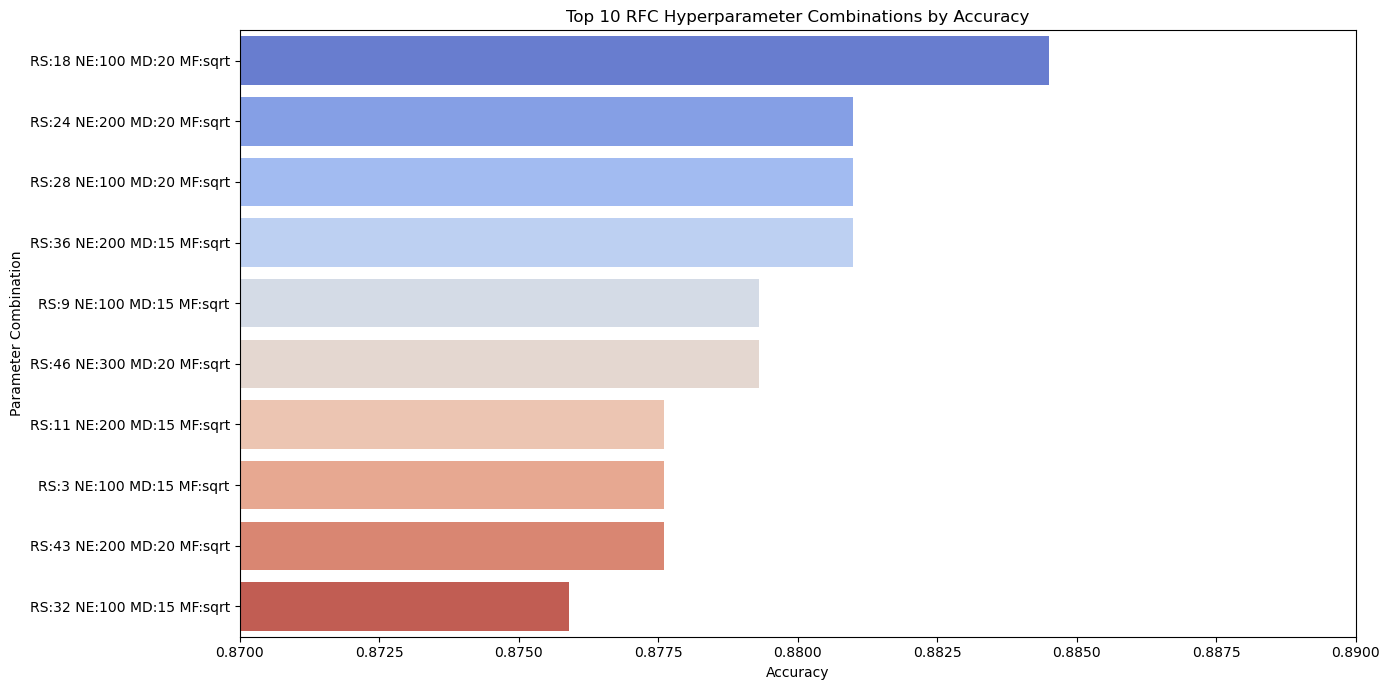

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 best hyperparameter combinations
data = [
    {'random_state': 18, 'n_estimators': 100, 'max_depth': 20, 'max_features': 'sqrt', 'accuracy': 0.8845},
    {'random_state': 24, 'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt', 'accuracy': 0.8810},
    {'random_state': 28, 'n_estimators': 100, 'max_depth': 20, 'max_features': 'sqrt', 'accuracy': 0.8810},
    {'random_state': 36, 'n_estimators': 200, 'max_depth': 15, 'max_features': 'sqrt', 'accuracy': 0.8810},
    {'random_state': 9,  'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'accuracy': 0.8793},
    {'random_state': 46, 'n_estimators': 300, 'max_depth': 20, 'max_features': 'sqrt', 'accuracy': 0.8793},
    {'random_state': 11, 'n_estimators': 200, 'max_depth': 15, 'max_features': 'sqrt', 'accuracy': 0.8776},
    {'random_state': 3,  'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'accuracy': 0.8776},
    {'random_state': 43, 'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt', 'accuracy': 0.8776},
    {'random_state': 32, 'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'accuracy': 0.8759}
]

# Create DataFrame
df = pd.DataFrame(data)

# Create label combining all hyperparameters
df['label'] = df.apply(
    lambda row: f"RS:{row['random_state']} NE:{row['n_estimators']} MD:{row['max_depth']} MF:{row['max_features']}",
    axis=1
)

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(x='accuracy', y='label', data=df, hue='label', palette='coolwarm', legend=False)
plt.title('Top 10 RFC Hyperparameter Combinations by Accuracy')
plt.xlabel('Accuracy')
plt.ylabel('Parameter Combination')
plt.xlim(0.87, 0.89)
plt.tight_layout()
plt.show()

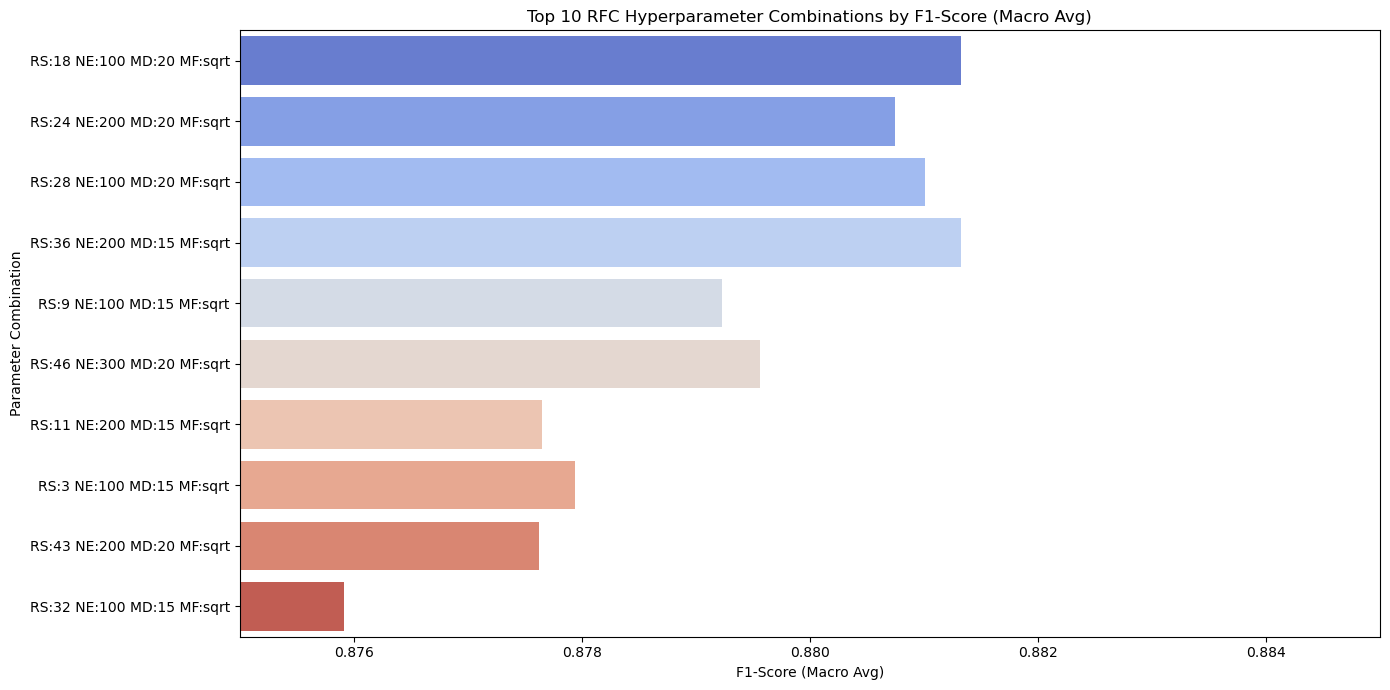

In [60]:
# Top 10 parameter combinations with macro average F1-scores from your file
data = [
    {'random_state': 18, 'n_estimators': 100, 'max_depth': 20, 'max_features': 'sqrt', 'f1_score': 0.88133},
    {'random_state': 24, 'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt', 'f1_score': 0.88075},
    {'random_state': 28, 'n_estimators': 100, 'max_depth': 20, 'max_features': 'sqrt', 'f1_score': 0.88101},
    {'random_state': 36, 'n_estimators': 200, 'max_depth': 15, 'max_features': 'sqrt', 'f1_score': 0.88133},
    {'random_state': 9,  'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'f1_score': 0.87923},
    {'random_state': 46, 'n_estimators': 300, 'max_depth': 20, 'max_features': 'sqrt', 'f1_score': 0.87956},
    {'random_state': 11, 'n_estimators': 200, 'max_depth': 15, 'max_features': 'sqrt', 'f1_score': 0.87765},
    {'random_state': 3,  'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'f1_score': 0.87794},
    {'random_state': 43, 'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt', 'f1_score': 0.87763},
    {'random_state': 32, 'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'f1_score': 0.87592}
]

# Create DataFrame
df = pd.DataFrame(data)
df['label'] = df.apply(
    lambda row: f"RS:{row['random_state']} NE:{row['n_estimators']} MD:{row['max_depth']} MF:{row['max_features']}",
    axis=1
)

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(x='f1_score', y='label', data=df,hue='label', palette='coolwarm')
plt.title('Top 10 RFC Hyperparameter Combinations by F1-Score (Macro Avg)')
plt.xlabel('F1-Score (Macro Avg)')
plt.ylabel('Parameter Combination')
plt.xlim(0.875, 0.885)
plt.tight_layout()
plt.show()

In [62]:
classifier = RandomForestClassifier(n_estimators=100, max_depth=20, max_features='sqrt', random_state=18)


classifier.fit(X_train, Y_train)

RandomForestClassifier(max_depth=20, random_state=18)

In [64]:
rf_pred = classifier.predict(X_test)

rf_accuracy = accuracy_score(Y_test, rf_pred)

print("Accuracy : ", rf_accuracy)

Accuracy :  0.8844827586206897


In [66]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, rf_pred))

              precision    recall  f1-score   support

           3       0.99      1.00      0.99        97
           4       0.91      0.98      0.94        92
           5       0.85      0.70      0.77       108
           6       0.73      0.68      0.71        95
           7       0.82      0.98      0.90        96
           8       1.00      0.99      0.99        92

    accuracy                           0.88       580
   macro avg       0.88      0.89      0.88       580
weighted avg       0.88      0.88      0.88       580



### Highest Quality (greater than 7)